In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [2]:
# Load semua file
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')
links = pd.read_csv('links.csv')

print("movies shape  :", movies.shape)
print("ratings shape :", ratings.shape)
print("tags shape    :", tags.shape)
print("links shape   :", links.shape)

movies shape  : (9742, 3)
ratings shape : (100836, 4)
tags shape    : (3683, 4)
links shape   : (9742, 3)


In [3]:
print("=== MOVIES ===")
display(movies.head())

print("=== RATINGS ===")
display(ratings.head())

print("=== TAGS ===")
display(tags.head())

=== MOVIES ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


=== RATINGS ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


=== TAGS ===


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [4]:
#Cek Missing Values & Duplikat
print("=== MISSING VALUES ===")
print("movies :")
print(movies.isnull().sum())
print()
print("ratings:")
print(ratings.isnull().sum())
print()
print("=== DUPLIKAT ===")
print("movies duplicates :", movies.duplicated().sum())
print("ratings duplicates:", ratings.duplicated().sum())

=== MISSING VALUES ===
movies :
movieId    0
title      0
genres     0
dtype: int64

ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

=== DUPLIKAT ===
movies duplicates : 0
ratings duplicates: 0


In [5]:
#Statistik Rating
print("Statistik Rating:")
print(ratings['rating'].describe())
print()
print("Distribusi Rating:")
print(ratings['rating'].value_counts().sort_index())

Statistik Rating:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Distribusi Rating:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


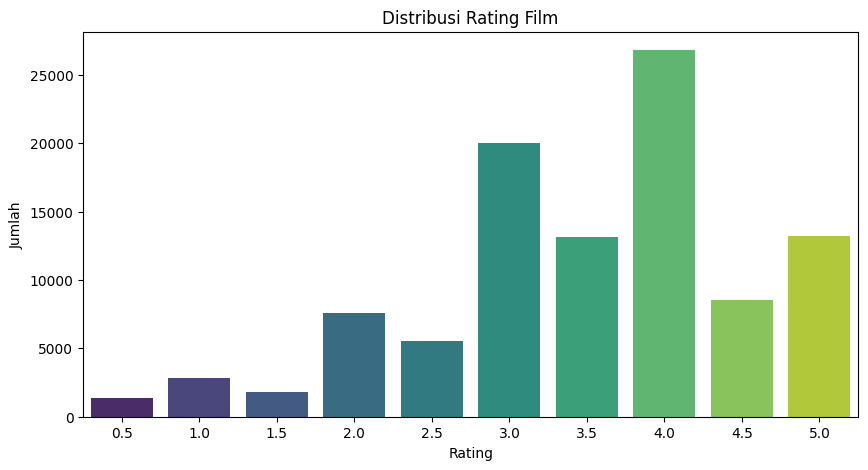

In [6]:
#Visualisasi Distribusi Rating
plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribusi Rating Film')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()

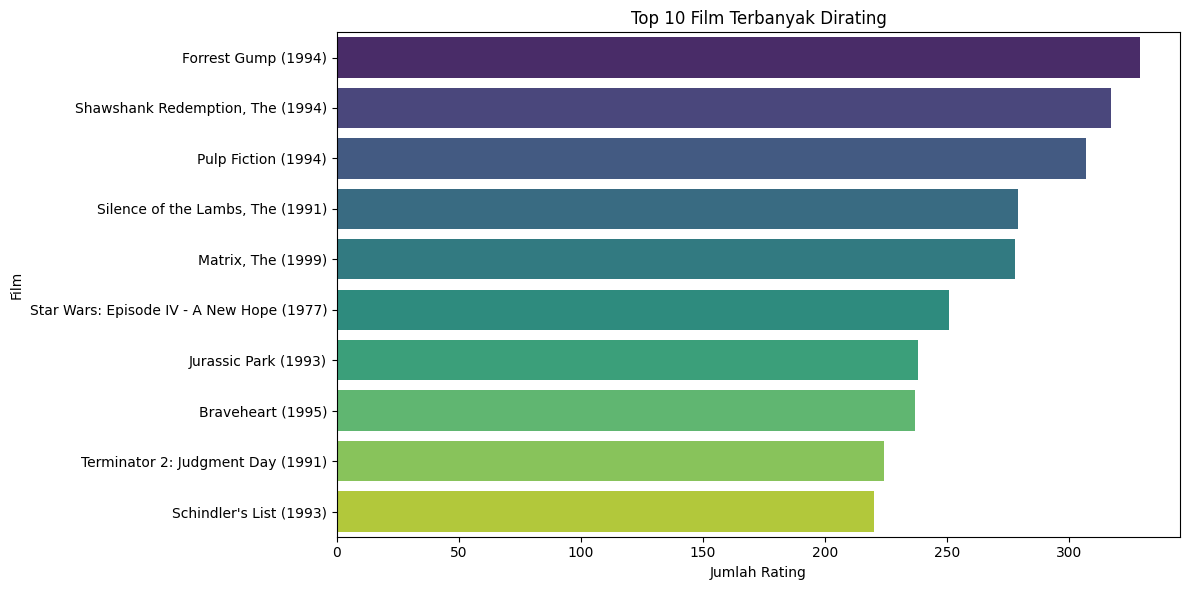

In [7]:
#Top 10 Film Terbanyak Dirating
top_rated = ratings.groupby('movieId')['rating'].count()\
            .reset_index()\
            .rename(columns={'rating': 'total_ratings'})\
            .sort_values('total_ratings', ascending=False)\
            .head(10)

top_rated = top_rated.merge(movies[['movieId', 'title']], on='movieId')

plt.figure(figsize=(12, 6))
sns.barplot(x='total_ratings', y='title', data=top_rated, palette='viridis')
plt.title('Top 10 Film Terbanyak Dirating')
plt.xlabel('Jumlah Rating')
plt.ylabel('Film')
plt.tight_layout()
plt.show()

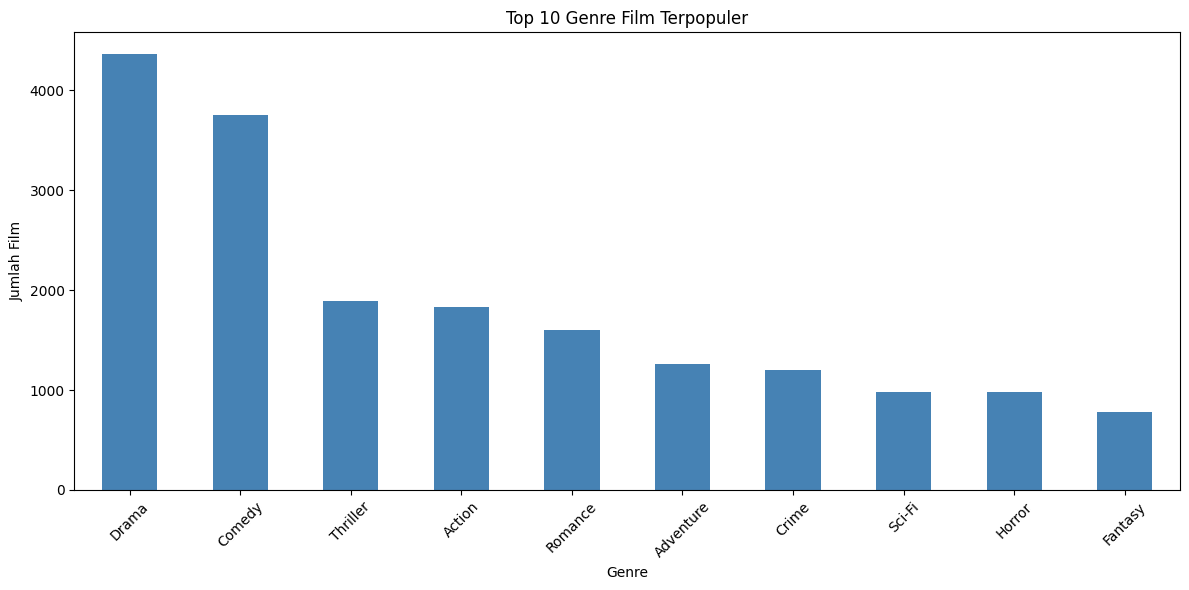

In [8]:
#Top 10 Genre Terpopuler
genres = movies['genres'].str.split('|').explode()
plt.figure(figsize=(12, 6))
genres.value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Genre Film Terpopuler')
plt.xlabel('Genre')
plt.ylabel('Jumlah Film')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Content-Based Filtering
# Menggunakan genre sebagai fitur utama

# Gabungkan tags ke movies
tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
movies_merged = movies.merge(tags_grouped, on='movieId', how='left')
movies_merged['tag'] = movies_merged['tag'].fillna('')

# Gabungkan genre dan tag menjadi satu fitur
movies_merged['genres_clean'] = movies_merged['genres'].str.replace('|', ' ', regex=False)
movies_merged['content'] = movies_merged['genres_clean'] + ' ' + movies_merged['tag']

movies_merged[['title', 'content']].head()

,title,content
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy pi...
1,Jumanji (1995),Adventure Children Fantasy fantasy magic board...
2,Grumpier Old Men (1995),Comedy Romance moldy old
3,Waiting to Exhale (1995),Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy pregnancy remake


In [10]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies_merged['content'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (9742, 1677)


In [11]:
# Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (9742, 9742)


In [12]:
# Fungsi Rekomendasi Content-Based
# Buat index berdasarkan judul film
indices = pd.Series(movies_merged.index, index=movies_merged['title']).drop_duplicates()

def get_content_recommendations(title, n=10):
    # Cek apakah film ada di dataset
    if title not in indices:
        return f"Film '{title}' tidak ditemukan di dataset!"
    
    # Ambil index film
    idx = indices[title]
    
    # Hitung similarity score
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    
    # Ambil index film yang direkomendasikan
    movie_indices = [i[0] for i in sim_scores]
    
    # Return judul dan genre film
    result = movies_merged[['title', 'genres']].iloc[movie_indices].copy()
    result['similarity_score'] = [round(i[1], 4) for i in sim_scores]
    return result.reset_index(drop=True)

In [ ]:
# Test Content-Based Recommendations
print("=== REKOMENDASI BERDASARKAN: Toy Story (1995) ===")
display(get_content_recommendations('Toy Story (1995)'))

=== REKOMENDASI BERDASARKAN: Toy Story (1995) ===


,title,genres,similarity_score
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8622
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.6440
2,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.3677
3,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.3579
4,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.3579
5,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.3579
6,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.3579
7,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.3579
8,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.3579
9,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.3579


In [14]:
# Collaborative Filtering
# Buat user-movie matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

User-Movie Matrix Shape: (610, 9724)


In [15]:
# Item-Based Collaborative Filtering
item_similarity = cosine_similarity(user_movie_matrix.T)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

print("Item Similarity Matrix Shape:", item_similarity_df.shape)

Item Similarity Matrix Shape: (9724, 9724)


In [16]:
# Fungsi Rekomendasi Collaborative Filtering
def get_collaborative_recommendations(movie_title, n=10):
    # Cari movieId berdasarkan judul
    movie_list = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    
    if movie_list.empty:
        return f"Film '{movie_title}' tidak ditemukan!"
    
    movie_id = movie_list.iloc[0]['movieId']
    
    if movie_id not in item_similarity_df.index:
        return f"Film tidak memiliki cukup rating!"
    
    # Ambil similarity score
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    
    # Gabungkan dengan info film
    result = pd.DataFrame({'movieId': sim_scores.index, 'similarity_score': sim_scores.values})
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    return result[['title', 'genres', 'similarity_score']].reset_index(drop=True)

In [17]:
# Cell 17 - Test Collaborative Filtering
print("=== REKOMENDASI COLLABORATIVE: Toy Story ===")
display(get_collaborative_recommendations('Toy Story'))

=== REKOMENDASI COLLABORATIVE: Toy Story ===


,title,genres,similarity_score
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.572601
1,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.565637
2,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.564262
3,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.557388
4,Forrest Gump (1994),Comedy|Drama|Romance|War,0.547096
5,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.541145
6,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.541089
7,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.538913
8,Groundhog Day (1993),Comedy|Fantasy|Romance,0.534169
9,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.530381


In [18]:
# Hybrid Recommendation
def get_hybrid_recommendations(movie_title, n=10):
    # Content-Based scores
    if movie_title not in indices:
        return f"Film '{movie_title}' tidak ditemukan!"
    
    idx = indices[movie_title]
    content_scores = pd.Series(cosine_sim[idx], index=movies_merged['title'])
    content_scores = content_scores.drop(movie_title)
    
    # Collaborative scores
    movie_list = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if not movie_list.empty:
        movie_id = movie_list.iloc[0]['movieId']
        if movie_id in item_similarity_df.index:
            collab_scores = item_similarity_df[movie_id]
            collab_scores.index = movies.set_index('movieId').loc[collab_scores.index, 'title']
        else:
            collab_scores = pd.Series(0, index=content_scores.index)
    else:
        collab_scores = pd.Series(0, index=content_scores.index)

    # Gabungkan kedua score (bobot 50:50)
    hybrid = pd.DataFrame({
        'content_score'  : content_scores,
        'collab_score'   : collab_scores
    }).fillna(0)

    hybrid['hybrid_score'] = 0.5 * hybrid['content_score'] + 0.5 * hybrid['collab_score']
    hybrid = hybrid.sort_values('hybrid_score', ascending=False).head(n)

    # Gabungkan dengan info film
    result = hybrid.reset_index().rename(columns={'index': 'title'})
    result = result.merge(movies[['title', 'genres']], on='title', how='left')
    return result[['title', 'genres', 'content_score', 'collab_score', 'hybrid_score']].reset_index(drop=True)

In [19]:
# Test Hybrid Recommendations
print("=== REKOMENDASI HYBRID: Toy Story (1995) ===")
display(get_hybrid_recommendations('Toy Story (1995)'))

=== REKOMENDASI HYBRID: Toy Story (1995) ===


,title,genres,content_score,collab_score,hybrid_score
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862225,0,0.431112
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644038,0,0.322019
2,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.367650,0,0.183825
3,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
4,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
5,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
6,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
7,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
8,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956
9,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.357912,0,0.178956


In [20]:
# Evaluasi dengan RMSE (Collaborative Filtering)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split data
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# Hitung rata-rata rating per film dari data training
movie_avg_rating = train_data.groupby('movieId')['rating'].mean()

# Prediksi rating pada test data
test_data = test_data.copy()
test_data['predicted_rating'] = test_data['movieId'].map(movie_avg_rating)
test_data['predicted_rating'] = test_data['predicted_rating'].fillna(ratings['rating'].mean())

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(test_data['rating'], test_data['predicted_rating']))
print(f"RMSE Baseline (Movie Average): {rmse:.4f}")

RMSE Baseline (Movie Average): 0.9827


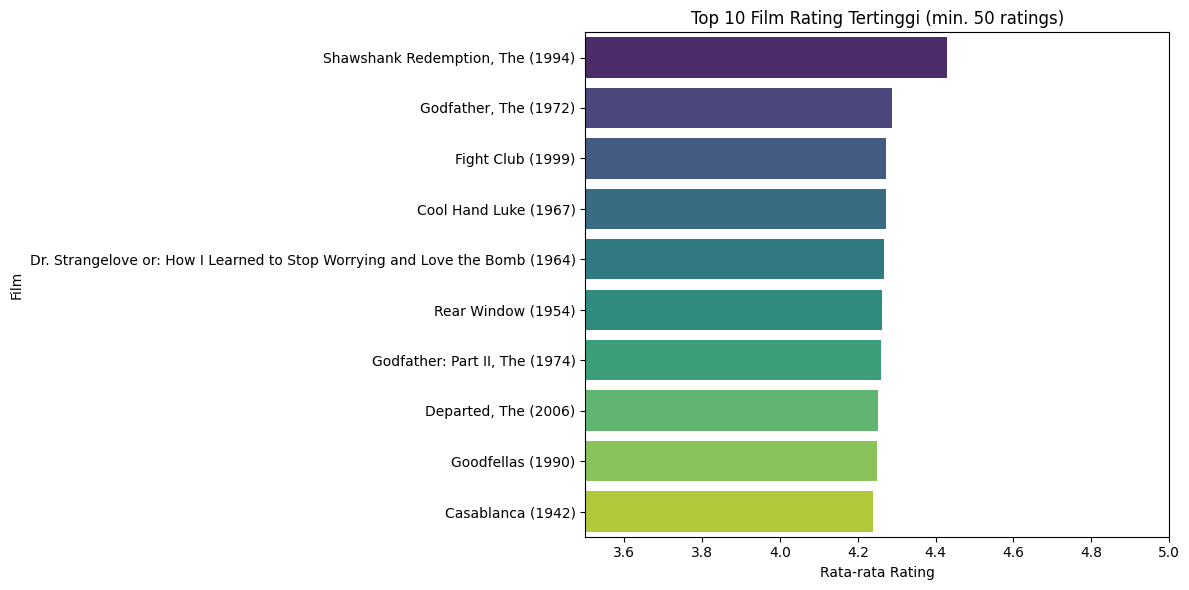

In [21]:
# Visualisasi Top 10 Film Rata-rata Rating Tertinggi
# Filter film dengan minimal 50 rating
movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    total_ratings=('rating', 'count')
).reset_index()

movie_stats = movie_stats[movie_stats['total_ratings'] >= 50]
movie_stats = movie_stats.merge(movies[['movieId', 'title']], on='movieId')
top_movies = movie_stats.sort_values('avg_rating', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='avg_rating', y='title', data=top_movies, palette='viridis')
plt.title('Top 10 Film Rating Tertinggi (min. 50 ratings)')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Film')
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.savefig('top_movies.png', dpi=150)
plt.show()

In [ ]:
# Simpan Model
joblib.dump(tfidf, 'tfidf_model.pkl')
joblib.dump(cosine_sim, 'cosine_sim.pkl')
joblib.dump(movies_merged, 'movies_data.pkl')
print("✅ Model berhasil disimpan!")

✅ Model berhasil disimpan!


In [23]:
# Perbaiki Hybrid Recommendation
def get_hybrid_recommendations_v2(movie_title, n=10):
    # Content-Based scores
    if movie_title not in indices:
        return f"Film '{movie_title}' tidak ditemukan!"
    
    idx = indices[movie_title]
    content_scores = pd.Series(cosine_sim[idx], index=movies_merged.index)
    content_scores = content_scores.drop(idx)

    # Collaborative scores
    movie_list = movies[movies['title'] == movie_title]
    if not movie_list.empty:
        movie_id = movie_list.iloc[0]['movieId']
        if movie_id in item_similarity_df.index:
            collab_raw = item_similarity_df[movie_id].drop(movie_id)
            # Map movieId ke index movies_merged
            mid_to_idx = movies_merged.reset_index().set_index('movieId')['index']
            collab_scores = collab_raw.index.map(
                lambda x: (mid_to_idx[x], collab_raw[x]) if x in mid_to_idx else None
            )
            collab_scores = pd.Series(
                {k: v for k, v in collab_scores if k is not None}
            )
        else:
            collab_scores = pd.Series(dtype=float)
    else:
        collab_scores = pd.Series(dtype=float)

    # Gabungkan score
    hybrid = pd.DataFrame({
        'content_score': content_scores,
        'collab_score' : collab_scores
    }).fillna(0)

    hybrid['hybrid_score'] = 0.5 * hybrid['content_score'] + 0.5 * hybrid['collab_score']
    hybrid = hybrid.sort_values('hybrid_score', ascending=False).head(n)

    # Gabungkan dengan info film
    result = movies_merged[['title', 'genres']].iloc[hybrid.index].copy()
    result['content_score'] = hybrid['content_score'].values
    result['collab_score']  = hybrid['collab_score'].values
    result['hybrid_score']  = hybrid['hybrid_score'].values
    return result.reset_index(drop=True)

# Test
print("=== REKOMENDASI HYBRID V2: Toy Story (1995) ===")
display(get_hybrid_recommendations_v2('Toy Story (1995)'))

=== REKOMENDASI HYBRID V2: Toy Story (1995) ===


,title,genres,content_score,collab_score,hybrid_score
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862225,0.479241,0.670733
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644038,0.572601,0.608320
2,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.357912,0.504650,0.431281
3,Willy Wonka & the Chocolate Factory (1971),Children|Comedy|Fantasy|Musical,0.208871,0.512246,0.360558
4,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.191120,0.527859,0.359490
5,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.357912,0.360652,0.359282
6,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.293014,0.417090,0.355052
7,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.177131,0.527977,0.352554
8,Groundhog Day (1993),Comedy|Fantasy|Romance,0.162255,0.534169,0.348212
9,Ice Age (2002),Adventure|Animation|Children|Comedy,0.313323,0.382734,0.348029


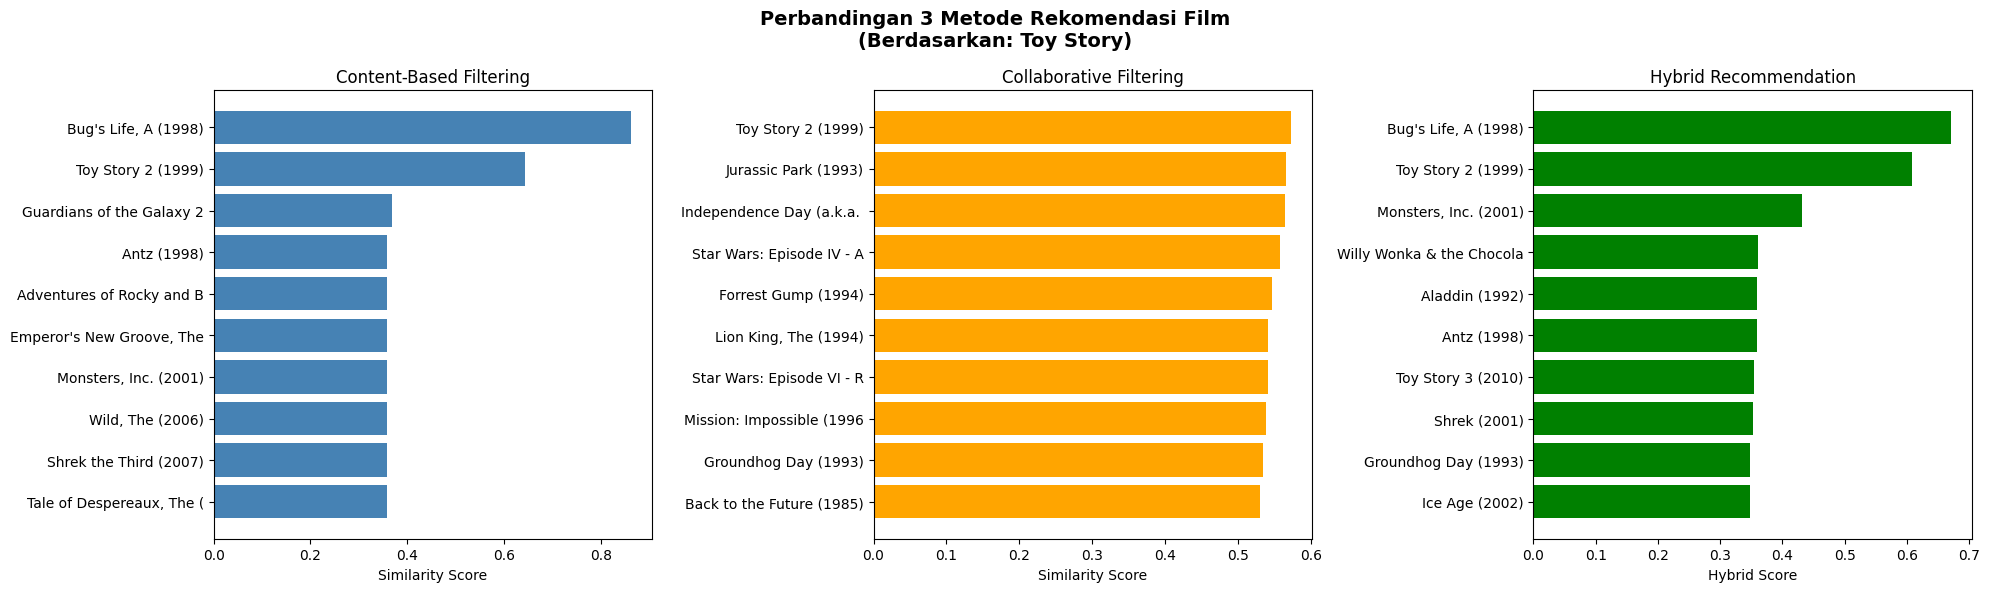

In [24]:
# Visualisasi Perbandingan 3 Metode Rekomendasi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Content-Based
cb = get_content_recommendations('Toy Story (1995)')
axes[0].barh(cb['title'].str[:25], cb['similarity_score'], color='steelblue')
axes[0].set_title('Content-Based Filtering')
axes[0].set_xlabel('Similarity Score')
axes[0].invert_yaxis()

# Collaborative
cf = get_collaborative_recommendations('Toy Story')
axes[1].barh(cf['title'].str[:25], cf['similarity_score'], color='orange')
axes[1].set_title('Collaborative Filtering')
axes[1].set_xlabel('Similarity Score')
axes[1].invert_yaxis()

# Hybrid
hb = get_hybrid_recommendations_v2('Toy Story (1995)')
axes[2].barh(hb['title'].str[:25], hb['hybrid_score'], color='green')
axes[2].set_title('Hybrid Recommendation')
axes[2].set_xlabel('Hybrid Score')
axes[2].invert_yaxis()

plt.suptitle('Perbandingan 3 Metode Rekomendasi Film\n(Berdasarkan: Toy Story)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('recommendation_comparison.png', dpi=150)
plt.show()

In [26]:
# Ringkasan Final
print("=" * 60)
print("RINGKASAN SISTEM REKOMENDASI FILM")
print("=" * 60)
print(f"Total Film     : {len(movies):,}")
print(f"Total User     : {ratings['userId'].nunique():,}")
print(f"Total Rating   : {len(ratings):,}")
print(f"Rata-rata Rating: {ratings['rating'].mean():.2f}")
print(f"RMSE Baseline  : 0.9827")
print()
print("Metode yang digunakan:")
print("  1. Content-Based Filtering (TF-IDF + Cosine Similarity)")
print("  2. Collaborative Filtering (Item-Based Cosine Similarity)")
print("  3. Hybrid Recommendation  (Content 50% + Collaborative 50%)")
print()
print("✅ Sistem rekomendasi berhasil dibangun!")

RINGKASAN SISTEM REKOMENDASI FILM
Total Film     : 9,742
Total User     : 610
Total Rating   : 100,836
Rata-rata Rating: 3.50
RMSE Baseline  : 0.9827

Metode yang digunakan:
  1. Content-Based Filtering (TF-IDF + Cosine Similarity)
  2. Collaborative Filtering (Item-Based Cosine Similarity)
  3. Hybrid Recommendation  (Content 50% + Collaborative 50%)

✅ Sistem rekomendasi berhasil dibangun!


In [27]:
# Cell 26 - Simpan Semua Model
joblib.dump(tfidf, 'tfidf_model.pkl')
joblib.dump(cosine_sim, 'cosine_sim.pkl')
joblib.dump(movies_merged, 'movies_data.pkl')
joblib.dump(item_similarity_df, 'item_similarity.pkl')
print("✅ Semua model berhasil disimpan!")

✅ Semua model berhasil disimpan!
